In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Wafer Map Defect Classification — Exploratory Data Analysis

Goal for this notebook (Milestone 1):
1. Load the WM-811K dataset
2. Understand class distribution (and confirm the imbalance problem)
3. Visualize sample wafer maps for each defect class
4. Understand image size variability (wafers are NOT all the same shape)

NOTE: Open this file in Jupyter and it will render as a notebook
(VS Code / JupyterLab both support the "py:percent" format directly).
If you prefer a real .ipynb, run: `jupytext --to notebook 01_eda.py`

In [9]:
import sys
sys.path.append("../src")



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_labeled_dataset, get_class_distribution, DEFECT_CLASSES

sns.set_style("whitegrid")

In [10]:
import os
print(os.getcwd())

C:\Users\nihaarika\PycharmProjects\WaferDefectClassification\notebooks


## 1. Load data

Download LSWMD.pkl from Kaggle first:
https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map
and place it at `../data/LSWMD.pkl`

In [12]:
df = load_labeled_dataset("../data/LSWMD.pkl")
df.head(20)

Loaded 811457 total wafers, 172950 labeled.


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,label
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]],none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]],none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]],none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]],none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]],none
5,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,6.0,[[Training]],[[none]],none
6,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,7.0,[[Training]],[[none]],none
7,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,8.0,[[Training]],[[none]],none
8,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,9.0,[[Training]],[[none]],none
9,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,10.0,[[Training]],[[none]],none


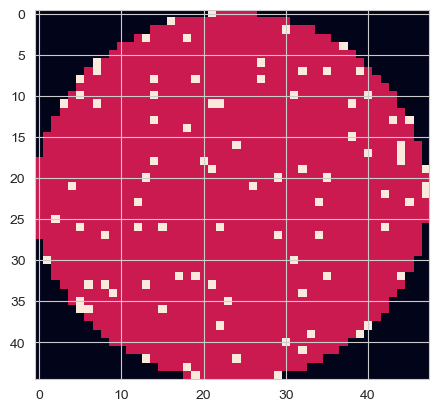

<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt
plt.imshow(df["waferMap"].iloc[0])
plt.show()
plt.savefig("../reports/figures/testwafermap.png")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172950 entries, 0 to 172949
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        172950 non-null  object 
 1   dieSize         172950 non-null  float64
 2   lotName         172950 non-null  object 
 3   waferIndex      172950 non-null  float64
 4   trianTestLabel  172950 non-null  object 
 5   failureType     172950 non-null  object 
 6   label           172950 non-null  object 
dtypes: float64(2), object(5)
memory usage: 9.2+ MB


In [22]:
df["failureType"].value_counts()

failureType
[[none]]         147431
[[Edge-Ring]]      9680
[[Edge-Loc]]       5189
[[Center]]         4294
[[Loc]]            3593
[[Scratch]]        1193
[[Random]]          866
[[Donut]]           555
[[Near-full]]       149
Name: count, dtype: int64

In [13]:
df["label"].value_counts()

label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

In [26]:
df["waferMap"].iloc[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

## 2. Class distribution

This is the single most important chart in this notebook. Real fab data
is heavily imbalanced — most wafers are defect-free or fall into a
handful of common categories, while some patterns (e.g. Near-full) are
rare. This is exactly the kind of imbalance a process/yield engineer
deals with in practice, and it directly shapes the modeling choices
in Milestone 3 (weighted loss / augmentation / resampling).

label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


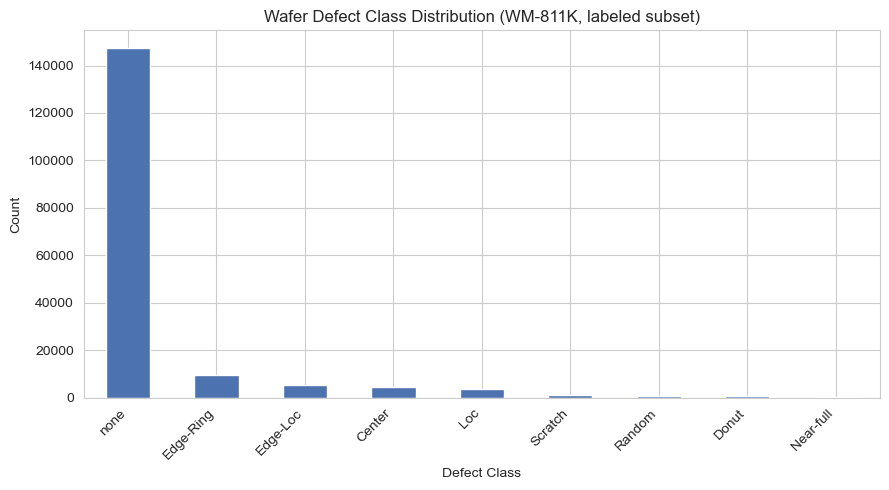

In [5]:
dist = get_class_distribution(df)
print(dist)

fig, ax = plt.subplots(figsize=(9, 5))
dist.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Wafer Defect Class Distribution (WM-811K, labeled subset)")
ax.set_ylabel("Count")
ax.set_xlabel("Defect Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=150)
plt.show()

## 3. Sample wafer maps per class

Visualizing a handful of examples per class builds intuition for what
the CNN will need to learn to distinguish — e.g. "Edge-Ring" is a ring
near the wafer boundary, "Center" is a cluster near the middle,
"Scratch" is a linear streak.

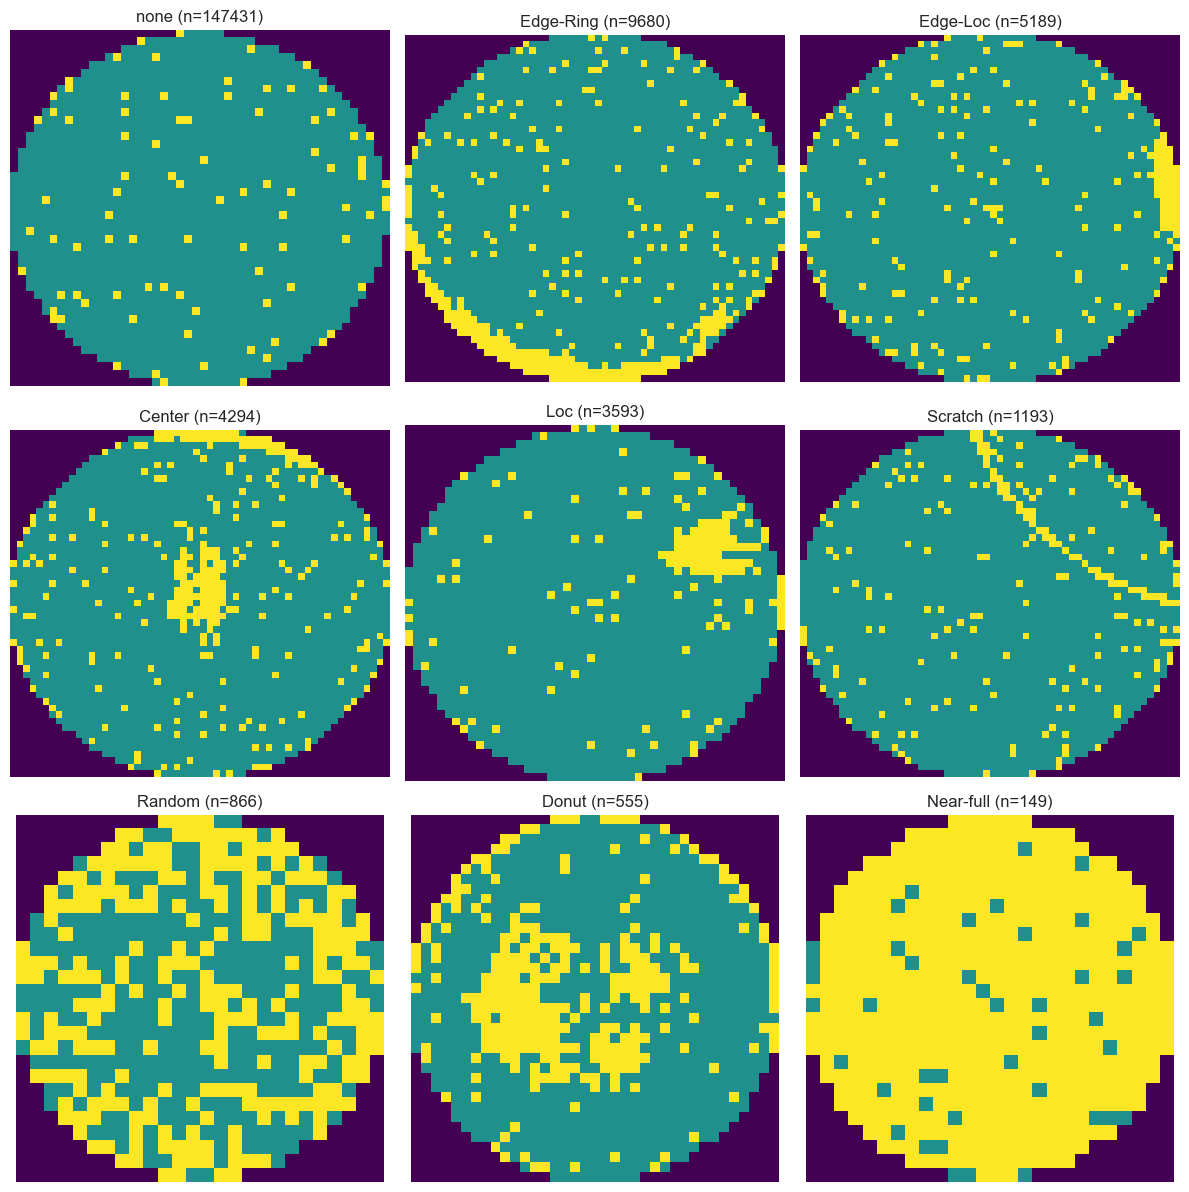

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, cls in enumerate(dist.index[:9]):
    sample = df[df["label"] == cls].iloc[0]
    axes[i].imshow(sample["waferMap"], cmap="viridis")
    axes[i].set_title(f"{cls} (n={dist[cls]})")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/sample_wafers_per_class.png", dpi=150)
plt.show()

## 4. Image size variability

Wafer maps are NOT a fixed resolution — die grid size varies by
product/lot. This matters directly for model design: we'll need a
resize/pad step before feeding into a CNN. Worth quantifying up front.

Most common wafer map shapes:
waferMap
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
(35, 31)     4331
(25, 26)     4174
(41, 38)     4152
(33, 37)     3729
(29, 27)     2872
Name: count, dtype: int64


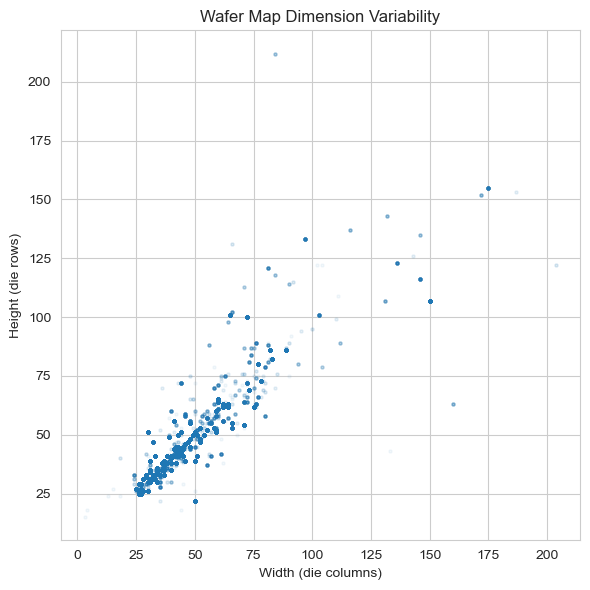

In [7]:
shapes = df["waferMap"].apply(lambda x: x.shape)
shape_counts = shapes.value_counts().head(15)
print("Most common wafer map shapes:")
print(shape_counts)

heights = shapes.apply(lambda s: s[0])
widths = shapes.apply(lambda s: s[1])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(widths, heights, alpha=0.05, s=5)
ax.set_xlabel("Width (die columns)")
ax.set_ylabel("Height (die rows)")
ax.set_title("Wafer Map Dimension Variability")
plt.tight_layout()
plt.savefig("../reports/figures/dimension_variability.png", dpi=150)
plt.show()

In [50]:

###Total labelled wafers#####
print(len(df))
print(df["label"].isna().sum())

####Most common class vs Raresr class ratio####

counts = df["label"].value_counts()

ratio = counts.max() / counts.min()

print("Common class /rare class " , ratio)

###Typical wafer map size ####

import pandas as pd

# Get the shape of each wafer map
shapes = df["waferMap"].apply(lambda x: x.shape)

# Count occurrences of each shape
shape_counts = shapes.value_counts()
most_common_shape = shape_counts.idxmax()
print("most common shape " , most_common_shape)


####Imbalance Ratio ##############

shapes = df["waferMap"].apply(lambda x: x.shape)
areas = shapes.apply(lambda s: s[0] * s[1])

min_idx = areas.idxmin()
max_idx = areas.idxmax()

print("Smallest wafer map shape:", shapes[min_idx], "-> area:", areas[min_idx])
print("Largest wafer map shape:", shapes[max_idx], "-> area:", areas[max_idx])
print("Area ratio (largest/smallest):", areas[max_idx] / areas[min_idx])

172950
0
Common class /rare class  989.4697986577181
most common shape  (25, 27)
Smallest wafer map shape: (15, 3) -> area: 45
Largest wafer map shape: (153, 187) -> area: 28611
Area ratio (largest/smallest): 635.8


Found 1 wafer(s) with shape (15, 3)
       label
109448  none


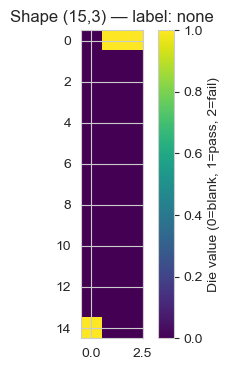

[[0 1 1]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [1 0 0]]


In [51]:
# Find and inspect the wafer(s) with the unusual (15, 3) shape

shapes = df["waferMap"].apply(lambda x: x.shape)
outlier_mask = shapes == (15, 3)

outlier_rows = df[outlier_mask]
print(f"Found {len(outlier_rows)} wafer(s) with shape (15, 3)")
print(outlier_rows[["label"]])  # what defect class is it labeled as?

# Visualize the first one
sample = outlier_rows.iloc[0]
plt.figure(figsize=(4, 4))
plt.imshow(sample["waferMap"], cmap="viridis")
plt.title(f"Shape (15,3) — label: {sample['label']}")
plt.colorbar(label="Die value (0=blank, 1=pass, 2=fail)")
plt.show()

# Also print the raw array itself — with only 45 values total, easy to eyeball directly
print(sample["waferMap"])

## 5. Takeaways (fill in after running)

- Total labeled wafers: 25519
- Most common class: ... / Rarest class: 990
- Imbalance ratio (largest class / smallest class): 635.8
- Typical wafer map size: ... (decide target resize dimension for CNN, e.g. 64x64)

**Next step (Milestone 2):** build a PyTorch Dataset that resizes/pads
wafer maps to a fixed size and trains a baseline CNN.

In [52]:
# Set a minimum area threshold to filter out degenerate/corrupted wafer maps
MIN_AREA = 100  # adjust based on your area distribution's lower percentiles

areas = shapes.apply(lambda s: s[0] * s[1])
df_clean = df[areas >= MIN_AREA].reset_index(drop=True)
print(f"Removed {len(df) - len(df_clean)} degenerate wafer maps (area < {MIN_AREA})")

Removed 2 degenerate wafer maps (area < 100)
